# Hybrid Quantum-Classical Reinforcement Learning (1/3)

___
___

## Introduction
___

This series of experiments is based on the 2025 paper by Nagy et al.: "[Hybrid Quantum-Classical Reinforcement Learning in Latent Observation Spaces](https://arxiv.org/abs/2410.18284)".

In this article, the authors apply hybrid quantum-classical Reinforcement Learning (RL) models to two simulated environments. They compare classical, qubit-based and photonic-based agents, all using Proximal Policy Optimization (PPO). They also use an AutoEncoder (AE) to compress the dimensionality of the observations and train that AE jointly with the PPO agents.

The notebook series aims to compare the resources cost of the different systems to reach the same performance. It is divided in three parts:

- **Part I: Classical vs Qubit agents on the Cart Pole environment**
- [Part II: Classical vs Qubit agents on the Lunar Lander and Maze environments](QRL_experiment_2.ipynb)
- [Part III: Photonic agents on the three environments](QRL_experiment_3.ipynb)

This first notebook will present:
1. The Cart Pole environment
2. AutoEncoders
3. Proximal Policy Optimization (PPO)
4. Classical PPO agent
5. Qubit-based PPO agent
6. Results
7. Conclusions
8. Follow-ups


In [1]:
# Uncomment the following line to install dependencies if needed
# !pip install ipynb torch torchvision gymnasium "gymnasium[classic-control]" matplotlib pennylane

In [2]:
import datetime
import random
import gc
import os
import time
import threading
import json
import psutil
from collections import namedtuple, deque
from itertools import count
import numpy as np
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
from matplotlib.colors import TABLEAU_COLORS
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import gymnasium as gym
import pennylane as qp

# For reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "cpu"
)

## 1 - The Cart Pole environment
___

In the article mentioned in the introduction, the authors use two environments: CartPole-v1 (OpenAI Gymnasium) and Maze-v0 (custom environment). For this experiment to run in a short amount of time, we will use CartPole-v1 only.

But first, a small refresher on Reinforcement Learning: in this sub-field of Machine Learning, an agent interacts with an environment and learns a policy that maximizes its rewards.

<div align="center">
<img src="images/qrl_demo_rl.png" width="600"/>
</div>

At each moment, the state of the environment is observed and the agent chooses an action accordingly. This action changes the environment, which gives a reward (depending on how good that action was for the overall objective) and the new state. The agent must learn to choose the best actions depending on the environment's state, in order to maximize the cumulative reward.

___

In the Cart Pole environment, the agent must learn to balance a pole on top of a cart by moving the cart left and right. 

<div align="center">
<img src="images/qrl_demo_cartpole.gif" width="300"/>
</div>

At each step, the agent receives four observations: the cart's position, its velocity, the pole's angle and the pole's angular velocity. From these observations, it must then choose between two actions: push the cart to the left or push the cart to the right.

The agent receives a +1 reward for each step where the pole is considered balanced (pole's angle greater than ±12°). The simulation (episode) ends when the pole is no longer balanced, when the cart's position is getting out of display or when the episode is > 500 steps.

More details about this environment can be found here: https://gymnasium.farama.org/environments/classic_control/cart_pole/.

In [3]:
# Create the Cart Pole environment with gymnasium
cartpole_env = gym.make("CartPole-v1", render_mode="rgb_array")
cartpole_env.reset(seed=seed)
cartpole_env.action_space.seed(seed)
cartpole_env.observation_space.seed(seed)

42

## 2 - AutoEncoders (AEs)
___

The Cart Pole environment contains four observations which can be reduced to only two variables with an AE.

AEs are used for dimensionality reduction, data compression and feature learning. They are composed of an encoder which produces a compressed representation of the original data, and a decoder which reconstructs the original data from the compressed, latent space representation.

<div align="center">
<img src="images/qrl_demo_autoencoder.png" width="600"/>
</div>

Therefore, AEs learn to create a relevant low-dimensional latent space representation of the original data. This is useful for quantum computing as it reduces the amount of data nodes (qubits/qumodes) needed and therefore computational cost.

Though AEs are usually trained in an unsupervised manner, learning to reconstruct the original data by themselves, the article's approach is different. Here, the authors choose to train the AE jointly with the PPO agents. This ensures that the latent space representation learned by the AE is specifically suited to this RL problem.

In [4]:
class EncoderDecoderNN(nn.Module):
    ''' The same model template can be used for both the Encoder and the Decoder, their dimensions will simply be mirrors of each other '''
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.layer2 = nn.Linear(hidden_dim, hidden_dim)
        self.layer3 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.layer1(x)
        x = F.relu(x)
        x = self.layer2(x)
        x = F.relu(x)
        return self.layer3(x)

class AutoEncoder(nn.Module):
    def __init__(self, input_shape, parameters):
        super().__init__()
        input_dim = input_shape[0]
        self.encoder = EncoderDecoderNN(input_dim, parameters["ae_hidden_dim"], parameters["ae_output_dim"])
        self.decoder = EncoderDecoderNN(parameters["ae_output_dim"], parameters["ae_hidden_dim"], input_dim)

## 3 - Proximal Policy Optimization (PPO)
___

The framework of Proximal Policy Optimization (PPO) involves two models: the Actor and the Critic. At each step, the Actor receives the compressed observations of the environment from the AE (the state representation) and outputs a probability distribution over the possible actions. An action is sampled from this distribution and executed in the environment.

The environment returns a reward for each action taken. The goal of PPO is to maximize the expected cumulative reward over an episode.

To achieve this, the Critic learns to associate each state with a value representing the expected cumulative future reward from that state. The Actor, meanwhile, learns a policy that assigns higher probabilities to actions that are expected to produce greater rewards.

<div align="center">
<img src="images/qrl_demo_classicalPPO.png" width="600"/>
</div>

To train both models, an advantage function is computed. It measures how much the observed returns based on the Actor's policy exceed the value predicted by the Critic for that state.

This advantage is then used to update both the Actor and the Critic. The Critic learns by minimizing the difference between its predicted state values and the observed returns collected during the rollout.

The Actor is updated by comparing the probability of the actions under the current policy with the probability under the policy that originally generated those actions. This probability ratio is multiplied by the advantage, so actions that produced higher-than-expected rewards become more likely, while those with lower-than-expected rewards become less likely.

To prevent excessively large policy updates that could destabilize learning, PPO uses the clipped surrogate objective. This objective limits how much the probability ratio can deviate from its previous value, preventing overly aggressive updates. The Actor is gradually optimized through backpropagation, resulting in more stable learning.

Finally, a Rollout Buffer is used to store the collected experiences (state, action, reward, next state, and related quantities such as the action log probability and estimated value). The Actor and Critic repeatedly sample from this buffer during each PPO update before a new rollout is collected.

In [5]:
class RolloutBuffer:
    ''' Stores Experiences at each step for the models to sample from '''
    def __init__(self, size):
        self.memory = deque([], maxlen=size)
        self.Experience = namedtuple(
            'Experience',
            ('state', 'action', 'action_log_probability', 'state_value', 'reward', 'done')
            )

    def add(self, *args):
        self.memory.append(self.Experience(*args))

    def get(self):
        batch = self.Experience(*zip(*self.memory))
        states = torch.squeeze(torch.cat(batch.state))
        actions = torch.squeeze(torch.cat(batch.action))
        action_log_probabilities = torch.squeeze(torch.cat(batch.action_log_probability))
        state_values = torch.squeeze(torch.cat(batch.state_value))
        rewards = np.array(batch.reward)
        dones = np.array(batch.done)
        return states, actions, action_log_probabilities, state_values, rewards, dones

class PPO:
    ''' Implements PPO with an AutoEncoder compressing the observations '''
    def __init__(self, AutoEncoderClass, ActorClass, CriticClass, env, config, custom_obs_shape=None):
        self.env = env
        self.config = config
        observations_shape = self.env.observation_space.shape
        if custom_obs_shape is not None:
            observations_shape = custom_obs_shape
        n_actions = self.env.action_space.n
        self.steps_update_frequency = self.env._max_episode_steps * self.config["episode_update_frequency"]

        self.buffer = RolloutBuffer(self.steps_update_frequency)
        self.autoencoder = AutoEncoderClass(observations_shape, self.config).to(device)
        self.actor = ActorClass(input_shape=self.config["ae_output_dim"], intermediate_dim=self.config["actor_intermediate_dim"], output_dim=n_actions).to(device)
        self.critic = CriticClass(input_shape=observations_shape, intermediate_dim=self.config["critic_intermediate_dim"], output_dim=1).to(device)
        self.optimizer = optim.Adam(list(self.autoencoder.parameters()) + list(self.actor.parameters()) + list(self.critic.parameters()), lr=self.config["lr"])

    def run(self):
        training_start = datetime.datetime.now()
        rewards = []
        mean_rewards = []
        mean_reward = 0
        total_timesteps = 0
        start = datetime.datetime.now()
        while mean_reward < self.config["mean_reward_stop"]:
            state, _ = self.env.reset()
            cumulative_reward = 0
            for _ in count():
                total_timesteps += 1

                state = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
                with torch.no_grad():
                    encoded_state = F.tanh(self.autoencoder.encoder(state))
                    action, action_log_probability, _, state_value = self.apply_policy(state, encoded_state)

                next_state, reward, terminated, truncated, _ = self.env.step(action.item())
                done = terminated or truncated

                self.buffer.add(state.detach(), action.detach(), action_log_probability.detach(), state_value.detach(), reward, done)

                cumulative_reward += reward

                state = next_state

                if total_timesteps % self.steps_update_frequency == 0:
                    self.optimize_models()
                    print()
                    print(f"Step {total_timesteps}: mean reward = {mean_reward:.2f} ({datetime.datetime.now()-start})")
                    start = datetime.datetime.now()

                if done:
                    break

            rewards.append(cumulative_reward)
            mean_reward = np.mean(rewards[-self.config["mean_reward_lookback"]:])
            mean_rewards.append(mean_reward)
        
        total_training_time = datetime.datetime.now()-training_start
        print(f"\nTotal training time: {total_training_time}")
        return mean_rewards, total_training_time.total_seconds()

    def apply_policy(self, state, encoded_state, action=None):
        actions_probs = F.softmax(self.actor(encoded_state), dim=-1)
        actions_distribution = torch.distributions.Categorical(actions_probs)
        if action is None:
            action = actions_distribution.sample()
        action_log_probability = actions_distribution.log_prob(action)
        distribution_entropy = actions_distribution.entropy()
        state_value = self.critic(state)
        return action, action_log_probability, distribution_entropy, state_value
    
    def optimize_models(self):
        states, actions, action_log_probabilities, state_values, rewards, dones = self.buffer.get()
        next_state_values = torch.cat([state_values[1:], torch.zeros(1, device=device)])

        advantages = []
        advantage = 0
        for reward, done, value, next_value in zip(
            reversed(rewards), reversed(dones), reversed(state_values), reversed(next_state_values)
        ):
            done_mask = 1.0 - done
            delta = reward + self.config["gamma"] * next_value * done_mask - value
            advantage = delta + self.config["gamma"] * self.config["lambda"] * done_mask * advantage
            advantages.insert(0, advantage)
        advantages = torch.stack(advantages)
        returns = advantages + state_values
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-9)

        mb_size = self.config["minibatch_size"]
        n = states.shape[0]
        for _ in range(self.config["K"]):
            rnd_permutations = torch.randperm(n, device=device)

            for start in range(0, n, mb_size):
                idx = rnd_permutations[start:start + mb_size]

                mb_states = states[idx]
                mb_actions = actions[idx]
                mb_old_log_probs = action_log_probabilities[idx]
                mb_advantages = advantages[idx]
                mb_returns = returns[idx]

                encoded_states = F.tanh(self.autoencoder.encoder(mb_states))
                reconstructed_states = self.autoencoder.decoder(encoded_states)
                
                _, new_action_log_probabilities, entropy, new_state_values = self.apply_policy(mb_states, encoded_states, mb_actions)
                new_state_values = torch.squeeze(new_state_values)
                
                policy_ratio = torch.exp(new_action_log_probabilities - mb_old_log_probs)
                objective = policy_ratio * mb_advantages
                clipped_objective = torch.clamp(
                    policy_ratio, min=1 - self.config["epsilon"], max=1 + self.config["epsilon"]
                ) * mb_advantages
                clipped_surrogate_loss = torch.min(objective, clipped_objective)

                ae_loss = F.mse_loss(reconstructed_states, mb_states).mean()
                policy_loss = -(clipped_surrogate_loss + self.config["entropy_coeff"] * entropy).mean()
                value_loss = F.mse_loss(new_state_values, mb_returns).mean()

                loss = ae_loss + policy_loss + 0.5 * value_loss

                self.optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.autoencoder.parameters(), 1.0)
                torch.nn.utils.clip_grad_norm_(self.actor.parameters(), 1.0)
                torch.nn.utils.clip_grad_norm_(self.critic.parameters(), 1.0)
                self.optimizer.step()

    def evaluate(self):
        fig, ax = plt.subplots()
        im = None

        state, _ = self.env.reset()
        for _ in count():

            state = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
            with torch.no_grad():
                encoded_state = F.tanh(self.autoencoder.encoder(state))
                actions_probs = F.softmax(self.actor(encoded_state), dim=-1)
                actions_distribution = torch.distributions.Categorical(actions_probs)
                action = actions_distribution.sample()

            next_state, _, terminated, truncated, _ = self.env.step(action.item())
            done = terminated or truncated
            state = next_state

            frame = self.env.render()
            if im is None:
                im = ax.imshow(frame)
                ax.axis("off")
            else:
                im.set_data(frame)
            clear_output(wait=True)
            display(fig)

            if done:
                break
            
        clear_output(wait=True)
        plt.close(fig)

## 4 - Classical PPO agent
___

In the classical case of PPO, both the Actor and the Critic are simple Neural Networks (NNs).

In [6]:
class ActorNN(nn.Module):
    ''' A simple Neural Network that will be the model basis for the Actor in the Classical PPO scenario '''
    def __init__(self, input_shape, intermediate_dim, output_dim):
        super().__init__()
        if isinstance(input_shape, int):
            input_dim = input_shape
        else:
            input_dim = input_shape[0]
        self.layer1 = nn.Linear(input_dim, intermediate_dim)
        self.layer2 = nn.Linear(intermediate_dim, output_dim)

    def forward(self, x):
        x = self.layer1(x)
        x = F.relu(x)
        return self.layer2(x)
    
class CriticNN(nn.Module):
    ''' A simple Neural Network that will be the model basis for the Critic in the Classical PPO scenario '''
    def __init__(self, input_shape, intermediate_dim, output_dim):
        super().__init__()
        if isinstance(input_shape, int):
            input_dim = input_shape
        else:
            input_dim = input_shape[0]
        self.layer1 = nn.Linear(input_dim, intermediate_dim)
        self.layer2 = nn.Linear(intermediate_dim, intermediate_dim)
        self.layer3 = nn.Linear(intermediate_dim, output_dim)

    def forward(self, x):
        x = self.layer1(x)
        x = F.relu(x)
        x = self.layer2(x)
        x = F.relu(x)
        return self.layer3(x)

## 5 - Qubit-based PPO agent
___

The quantum versions of PPO introduced in the article replace the actor NN by a Parametrized Quantum Circuit (PQC). In the case of the qubit-based PPO agent, the PQC consists of several layers of unitary operators. 

First, there is an encoding unitary for the latent representations of the AE, followed by several trainable rotation gates and CNOT blocks. We use data reuploading, by re-encoding the latent representations of the AE at the beginning of each layer.

With PennyLane, the circuit can be directly integrated as a PyTorch layer.

In [7]:
class ActorQubitNN(nn.Module):
    def __init__(self, input_shape, intermediate_dim, output_dim, seed=42):
        super().__init__()
        n_qubits = input_shape
        n_layers = intermediate_dim
        weight_shapes = {"weights": (n_layers, n_qubits)}
        dev = qp.device("default.qubit", wires=n_qubits, seed=seed)

        @qp.qnode(dev, interface='torch')
        def qnode(inputs, weights):
            for l in range(n_layers):
                qp.AngleEmbedding(inputs, wires=range(n_qubits))
                
                qp.BasicEntanglerLayers(
                    weights=weights[l].reshape(1, n_qubits),
                    wires=range(n_qubits),
                )
            return [qp.expval(qp.PauliZ(wires=i)) for i in range(n_qubits)]

        self.qlayer = qp.qnn.TorchLayer(qnode, weight_shapes)
        self.layer = nn.Linear(n_qubits, output_dim).to(device)

    def forward(self, x):
        x = self.qlayer(x.cpu()).to(device)
        return self.layer(x)

## 6 - Results
___

Before we launch the trainings, we need some additional functions to measure the memory allocated, count the parameters and save / plot the results.

In [8]:
class MemoryTracker:
    ''' Measures the peak memory used by the process by opening it in a thread and polling every few milliseconds '''
    def __init__(self):
        self.process = psutil.Process(os.getpid())
 
        if torch.cuda.is_available():
            self.device = "cuda"
        elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
            self.device = "mps"
        else:
            self.device = "cpu"
 
        self._stop_event = threading.Event()
        self._thread = None
        self._peak_rss = 0
        self._peak_mps = 0
 
    def _poll(self):
        while not self._stop_event.is_set():
            rss = self.process.memory_info().rss
            if rss > self._peak_rss:
                self._peak_rss = rss
            if self.device == "mps":
                cur_mps = torch.mps.current_allocated_memory()
                if cur_mps > self._peak_mps:
                    self._peak_mps = cur_mps
            time.sleep(0.05)
 
    def __enter__(self):
        gc.collect()
        if self.device == "cuda":
            torch.cuda.empty_cache()
            torch.cuda.reset_peak_memory_stats()
        elif self.device == "mps":
            torch.mps.empty_cache()
 
        self._baseline_rss = self.process.memory_info().rss
        self._peak_rss = self._baseline_rss
        self._peak_mps = 0
 
        self._stop_event.clear()
        self._thread = threading.Thread(target=self._poll, daemon=True)
        self._thread.start()
        return self
 
    def __exit__(self, exc_type, exc_val, exc_tb):
        rss = self.process.memory_info().rss
        self._peak_rss = max(self._peak_rss, rss)
 
        self._stop_event.set()
        self._thread.join()
 
        self.peak_rss_mb = self._peak_rss / 1024**2
        self.rss_increase_mb = (self._peak_rss - self._baseline_rss) / 1024**2
 
        if self.device == "cuda":
            self.peak_cuda_alloc_mb = torch.cuda.max_memory_allocated() / 1024**2
            self.peak_cuda_reserved_mb = torch.cuda.max_memory_reserved() / 1024**2
        elif self.device == "mps":
            self.peak_mps_mb = self._peak_mps / 1024**2

        return False

def count_parameters(model, trainable_only=True):
    ''' Counts the parameters in a model '''
    if trainable_only:
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    return sum(p.numel() for p in model.parameters())

def save_results(results_filepath, env_name, results_type, results):
    ''' Saves / adds the results of the models per environment '''
    qrl_results = {}
    if os.path.exists(results_filepath):
        with open(results_filepath, "r") as fp:
            qrl_results = json.load(fp)
    if env_name not in qrl_results:
        qrl_results[env_name] = {}
    qrl_results[env_name][results_type] = results
    with open(results_filepath, "w") as fp:
        json.dump(qrl_results, fp)
    return qrl_results

def plot_results(env_name, env_results, env_reward_stop, methods=["classical", "qubit"]):
    ''' Plots the results to compare training time, performances, number of parameters and memory used'''
    colors = []
    for i, color in enumerate(TABLEAU_COLORS):
        if i >= len(methods):
            break
        colors.append(color)
        
    _, axes = plt.subplots(2, 2)

    # Training time
    axes[0, 0].bar(methods, [env_results[method]["training_time"] for method in methods], color=colors)
    axes[0, 0].set_ylabel("Seconds")
    axes[0, 0].set_title("Training time")

    # Performance
    for method in methods:
        axes[0, 1].plot(env_results[method]["mean_rewards"])
    axes[0, 1].axhline(y=env_reward_stop, color="black")
    axes[0, 1].set_xlabel("Episodes")
    axes[0, 1].set_ylabel("Rewards Mean Average")
    axes[0, 1].yaxis.set_label_position("right")
    axes[0, 1].yaxis.tick_right()
    axes[0, 1].set_title("Performance")

    # Parameters
    axes[1, 0].bar(methods, [env_results[method]["parameters"] for method in methods], color=colors)
    axes[1, 0].set_ylabel("Number of parameters")
    axes[1, 0].set_title("Actor parameters")

    # Memory used
    axes[1, 1].bar(methods, [env_results[method]["memory"] for method in methods], color=colors)
    axes[1, 1].set_ylabel("Mb")
    axes[1, 1].yaxis.set_label_position("right")
    axes[1, 1].yaxis.tick_right()
    axes[1, 1].set_title("Memory used")

    plt.suptitle(f"Environment: {env_name}")
    plt.tight_layout()
    plt.show()

In [9]:
# We save the results in results/qrl_results.json
results_folder = "results"
os.makedirs(results_folder, exist_ok=True)
results_filepath = os.path.join(results_folder, "qrl_results.json")
env_name = "Cart Pole"

# Set the configuration for Cart Pole
cp_config = {
    "ae_hidden_dim": 32, "ae_output_dim": 2,
    "critic_intermediate_dim": 64, "minibatch_size": 128, "lr": 1e-3,
    "K": 10, "episode_update_frequency": 1, "mean_reward_lookback": 20, "mean_reward_stop": 480,
    "gamma": 0.98, "lambda": 0.8, "epsilon": 0.2, "entropy_coeff": 0.0
}

In [10]:
# 1. Classical PPO
cp_config["actor_intermediate_dim"] = 2
with MemoryTracker() as cp_classical_stats:
    cp_classical_ppo = PPO(AutoEncoderClass=AutoEncoder, ActorClass=ActorNN, CriticClass=CriticNN, env=cartpole_env, config=cp_config)
    cp_classical_parameters = count_parameters(cp_classical_ppo.actor)
    cp_classical_mean_rewards, cp_classical_training_time = cp_classical_ppo.run()
classical_results = { 
    "training_time": cp_classical_training_time, 
    "mean_rewards": cp_classical_mean_rewards, 
    "parameters": cp_classical_parameters, 
    "memory": cp_classical_stats.peak_rss_mb 
}
torch.save(cp_classical_ppo.autoencoder.state_dict(), os.path.join(results_folder, "cp_classical_ae.pt"))
torch.save(cp_classical_ppo.actor.state_dict(), os.path.join(results_folder, "cp_classical_actor.pt"))
torch.save(cp_classical_ppo.critic.state_dict(), os.path.join(results_folder, "cp_classical_critic.pt"))
qrl_results = save_results(results_filepath, env_name, "classical", classical_results)


Step 500: mean reward = 16.55 (0:00:00.181496)

Step 1000: mean reward = 15.25 (0:00:00.127050)

Step 1500: mean reward = 13.95 (0:00:00.128198)

Step 2000: mean reward = 15.05 (0:00:00.129276)

Step 2500: mean reward = 22.20 (0:00:00.130596)

Step 3000: mean reward = 31.40 (0:00:00.125793)

Step 3500: mean reward = 31.90 (0:00:00.126700)

Step 4000: mean reward = 28.70 (0:00:00.125593)

Step 4500: mean reward = 31.90 (0:00:00.126302)

Step 5000: mean reward = 48.15 (0:00:00.125995)

Step 5500: mean reward = 65.00 (0:00:00.126949)

Step 6000: mean reward = 75.70 (0:00:00.127260)

Step 6500: mean reward = 103.40 (0:00:00.126640)

Step 7000: mean reward = 116.30 (0:00:00.125256)

Step 7500: mean reward = 133.55 (0:00:00.126142)

Step 8000: mean reward = 145.70 (0:00:00.130216)

Step 8500: mean reward = 149.50 (0:00:00.125248)

Step 9000: mean reward = 172.40 (0:00:00.124418)

Step 9500: mean reward = 192.85 (0:00:00.125763)

Step 10000: mean reward = 200.85 (0:00:00.124272)

Step 10500:

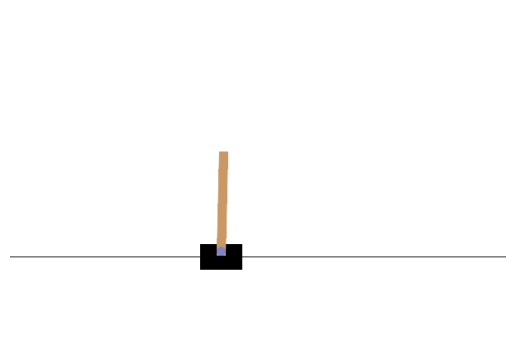

In [11]:
cp_classical_ppo.evaluate()

In [12]:
# 2. Qubit PPO
cp_config["actor_intermediate_dim"] = 3 # QNN Layers
with MemoryTracker() as cp_qubit_stats:
    cp_qubit_ppo = PPO(AutoEncoderClass=AutoEncoder, ActorClass=ActorQubitNN, CriticClass=CriticNN, env=cartpole_env, config=cp_config)
    cp_qubit_parameters = count_parameters(cp_qubit_ppo.actor)
    cp_qubit_mean_rewards, cp_qubit_training_time = cp_qubit_ppo.run()
qubit_results = { 
    "training_time": cp_qubit_training_time, 
    "mean_rewards": cp_qubit_mean_rewards, 
    "parameters": cp_qubit_parameters, 
    "memory": cp_qubit_stats.peak_rss_mb
}
torch.save(cp_qubit_ppo.autoencoder.state_dict(), os.path.join(results_folder, "cp_qubit_ae.pt"))
torch.save(cp_qubit_ppo.actor.state_dict(), os.path.join(results_folder, "cp_qubit_actor.pt"))
torch.save(cp_qubit_ppo.critic.state_dict(), os.path.join(results_folder, "cp_qubit_critic.pt"))
qrl_results = save_results(results_filepath, env_name, "qubit", qubit_results)


Step 500: mean reward = 24.90 (0:00:01.290992)

Step 1000: mean reward = 27.90 (0:00:01.249240)

Step 1500: mean reward = 32.50 (0:00:01.357588)

Step 2000: mean reward = 27.60 (0:00:01.328337)

Step 2500: mean reward = 34.20 (0:00:01.217765)

Step 3000: mean reward = 37.00 (0:00:01.275477)

Step 3500: mean reward = 40.00 (0:00:01.484112)

Step 4000: mean reward = 48.40 (0:00:01.431914)

Step 4500: mean reward = 58.05 (0:00:01.606464)

Step 5000: mean reward = 75.35 (0:00:01.555434)

Step 5500: mean reward = 82.25 (0:00:01.393375)

Step 6000: mean reward = 82.40 (0:00:01.544184)

Step 6500: mean reward = 72.30 (0:00:01.283369)

Step 7000: mean reward = 68.70 (0:00:01.241289)

Step 7500: mean reward = 83.20 (0:00:01.273533)

Step 8000: mean reward = 97.75 (0:00:01.380395)

Step 8500: mean reward = 106.20 (0:00:01.255267)

Step 9000: mean reward = 116.45 (0:00:01.203282)

Step 9500: mean reward = 123.00 (0:00:01.199727)

Step 10000: mean reward = 141.40 (0:00:01.204209)

Step 10500: mea

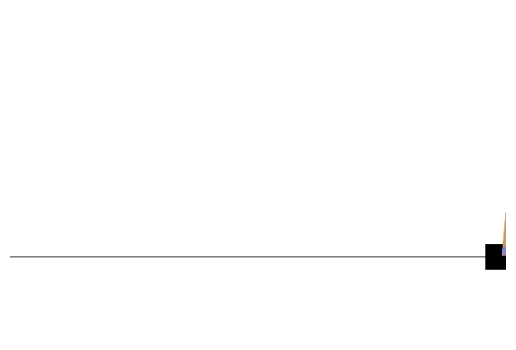

In [13]:
cp_qubit_ppo.evaluate()

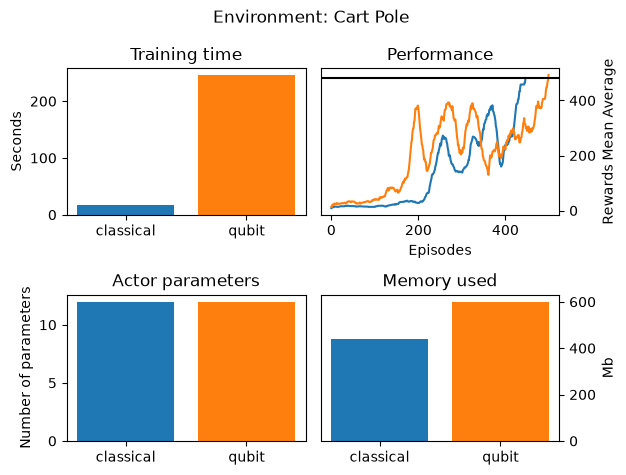

In [14]:
plot_results(env_name, qrl_results[env_name], cp_config["mean_reward_stop"])

## 7 - Conclusions
___

The models were prepared so that they'd have the same amount of parameters.

Both methods reached the expected performance, though the Qubit-based method took a bit more episodes to reach it. The training time was way longer for the Qubit-based PPO, and the memory consumption slightly higher.

It was not expected for the Qubit-based model to outclass the classical method on such a simple problem, but it is interesting to see how easy it was to implement and integrate into PyTorch. The higher training time and memory consumption are due to the fact that we trained on a simulator.

## 8 - Follow-ups
___

You can play around with the configuration : try using other values for actor_intermediate_dim in both cases to see how the results change.

In the next notebook, we'll use the same methods on two other environments: the Lunar Lander and a custom Maze environment. The training times will be longer as these environment are slightly more complicated.